<a href="https://colab.research.google.com/github/phaneendra-simhadri/phaneendra_ML/blob/main/Lab02_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd


def load_purchase_data(file_path, sheet_name):

    return pd.read_excel(file_path, sheet_name=sheet_name)


def extract_feature_matrix(dataframe):

    return dataframe[['Candies (#)', 'Mangoes (Kg)', 'Milk Packets (#)']].values


def extract_payment_vector(dataframe):

    return dataframe['Payment (Rs)'].values


def calculate_rank(feature_matrix):

    return np.linalg.matrix_rank(feature_matrix)


def calculate_product_costs(feature_matrix, payment_vector):

    pseudo_inverse = np.linalg.pinv(feature_matrix)
    product_costs = pseudo_inverse @ payment_vector
    return product_costs


def main():
    # File information
    file_path = "/content/Lab Session Data.xlsx"
    sheet_name = "Purchase data"

    # Load dataset
    purchase_data = load_purchase_data(file_path, sheet_name)

    # Extract input and output data
    feature_matrix = extract_feature_matrix(purchase_data)
    payment_vector = extract_payment_vector(purchase_data)

    # Compute rank
    matrix_rank = calculate_rank(feature_matrix)

    # Compute product costs
    product_costs = calculate_product_costs(feature_matrix, payment_vector)

    # Display results
    print("Rank of Feature Matrix:", matrix_rank)
    print(f"Candy        : ₹{product_costs[0]:.2f}")
    print(f"Mango (1 Kg) : ₹{product_costs[1]:.2f}")
    print(f"Milk Packet  : ₹{product_costs[2]:.2f}")


# Execute the program
if __name__ == "__main__":
    main()

Rank of Feature Matrix: 3
Candy        : ₹1.00
Mango (1 Kg) : ₹55.00
Milk Packet  : ₹18.00


In [ ]:
def load_purchase_data(file_path, sheet_name):

    return pd.read_excel(file_path, sheet_name=sheet_name)


def classify_customers(dataframe):

    dataframe["Class"] = dataframe["Payment (Rs)"].apply(
        lambda payment: "RICH" if payment > 200 else "POOR"
    )
    return dataframe


def main():

    file_path = "/content/Lab Session Data.xlsx"
    sheet_name = "Purchase data"

    purchase_data = load_purchase_data(file_path, sheet_name)

    purchase_data = classify_customers(purchase_data)

    print(purchase_data[['Customer', 'Payment (Rs)', 'Class']])


if __name__ == "__main__":
    main()

  Customer  Payment (Rs) Class
0      C_1           386  RICH
1      C_2           289  RICH
2      C_3           393  RICH
3      C_4           110  POOR
4      C_5           280  RICH
5      C_6           167  POOR
6      C_7           271  RICH
7      C_8           274  RICH
8      C_9           148  POOR
9     C_10           198  POOR


Population Mean (NumPy): 1560.6634538152612
Population Variance (NumPy): 58496.49239931618

Custom Mean: 1560.6634538152612
Custom Variance: 58496.49239931616

Average Execution Time (10 Runs)
NumPy Mean: 3.0214400067052338e-05
Custom Mean: 2.081279999401886e-05
NumPy Variance: 2.4554699848522432e-05
Custom Variance: 6.038630008333712e-05

Wednesday Sample Mean: 1550.7060000000001
April Sample Mean: 1698.9526315789474
Probability of Profit on Wednesday: 0.08433734939759036
Conditional Probability (Profit | Wednesday): 0.42


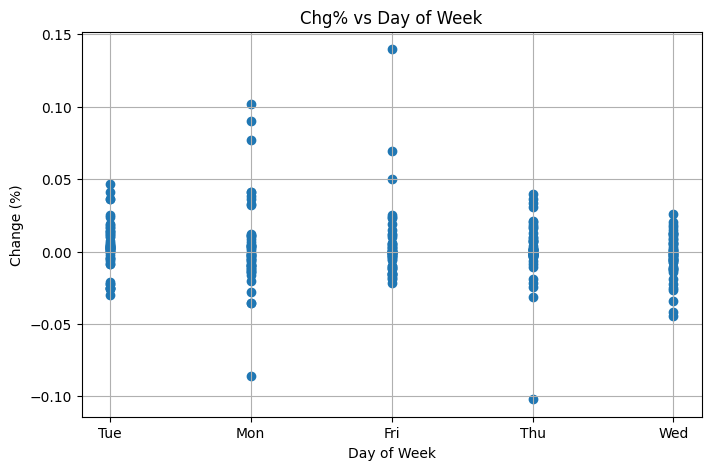

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time


def load_stock_data(file_path, sheet_name):

    dataframe = pd.read_excel(file_path, sheet_name=sheet_name)

    # Convert Price column to float
    dataframe["Price"] = dataframe["Price"].astype(str).str.replace(",", "", regex=False).astype(float)

    # Convert Chg% column to float
    dataframe["Chg%"] = (
        dataframe["Chg%"]
        .astype(str)
        .str.replace("%", "", regex=False)
        .astype(float)
    )

    return dataframe


def calculate_mean(values):

    return sum(values) / len(values)


def calculate_variance(values):

    mean = calculate_mean(values)

    variance = 0

    for value in values:
        variance += (value - mean) ** 2

    return variance / len(values)


def average_execution_time(function, values, runs=10):

    total_time = 0

    for _ in range(runs):
        start = time.perf_counter()
        function(values)
        end = time.perf_counter()
        total_time += (end - start)

    return total_time / runs




def main():

    file_path = "/content/Lab Session Data.xlsx"
    sheet_name = "IRCTC Stock Price"

    stock_data = load_stock_data(file_path, sheet_name)

    price = stock_data["Price"]

    # Mean and Variance using NumPy
    numpy_mean = np.mean(price)
    numpy_variance = np.var(price)

    # Mean and Variance using custom functions
    custom_mean = calculate_mean(price)
    custom_variance = calculate_variance(price)

    # Average execution time
    numpy_mean_time = average_execution_time(np.mean, price)
    custom_mean_time = average_execution_time(calculate_mean, price)

    numpy_variance_time = average_execution_time(np.var, price)
    custom_variance_time = average_execution_time(calculate_variance, price)

    # Wednesday sample mean
    wednesday_mean = np.mean(
        stock_data[stock_data["Day"] == "Wed"]["Price"]
    )

    # April sample mean
    april_mean = np.mean(
        stock_data[stock_data["Month"] == "Apr"]["Price"]
    )


    # Probability of profit on Wednesday
    probability_profit_wednesday = len(
        stock_data[
            (stock_data["Day"] == "Wed") &
            (stock_data["Chg%"] > 0)
        ]
    ) / len(stock_data)

    # Conditional probability of profit given Wednesday
    wednesday_data = stock_data[stock_data["Day"] == "Wed"]

    conditional_probability = len(
        wednesday_data[wednesday_data["Chg%"] > 0]
    ) / len(wednesday_data)

    # Print Results
    print("Population Mean (NumPy):", numpy_mean)
    print("Population Variance (NumPy):", numpy_variance)

    print("\nCustom Mean:", custom_mean)
    print("Custom Variance:", custom_variance)

    print("\nAverage Execution Time (10 Runs)")
    print("NumPy Mean:", numpy_mean_time)
    print("Custom Mean:", custom_mean_time)
    print("NumPy Variance:", numpy_variance_time)
    print("Custom Variance:", custom_variance_time)

    print("\nWednesday Sample Mean:", wednesday_mean)
    print("April Sample Mean:", april_mean)

    print("Probability of Profit on Wednesday:", probability_profit_wednesday)
    print("Conditional Probability (Profit | Wednesday):", conditional_probability)

    # Scatter Plot
    plt.figure(figsize=(8,5))
    plt.scatter(stock_data["Day"], stock_data["Chg%"])
    plt.xlabel("Day of Week")
    plt.ylabel("Change (%)")
    plt.title("Chg% vs Day of Week")
    plt.grid(True)
    plt.show()


if __name__ == "__main__":
    main()

In [3]:
import pandas as pd

df = pd.read_excel("/content/Lab Session Data.xlsx", sheet_name="thyroid0387_UCI", nrows = 0)

headers = df.columns.tolist()
print(headers)

#the attributes like record id, sex are nominal
#the attribute age is ratio, base line is fixed
#the other attributes which are either true or false are nominal
#the report values are ratio bcz they have true zero
#condition and referral source is also nominal








['Record ID', 'age', 'sex', 'on thyroxine', 'query on thyroxine', 'on antithyroid medication', 'sick', 'pregnant', 'thyroid surgery', 'I131 treatment', 'query hypothyroid', 'query hyperthyroid', 'lithium', 'goitre', 'tumor', 'hypopituitary', 'psych', 'TSH measured', 'TSH', 'T3 measured', 'T3', 'TT4 measured', 'TT4', 'T4U measured', 'T4U', 'FTI measured', 'FTI', 'TBG measured', 'TBG', 'referral source', 'Condition']


'\nthe attributes like record id, sex are nominal \n\nthe attribute age is ratio, base line is fixed\nthe other attributes which are either true or false are nominal\nthe report values are ratio bcz they have true zero\ncondition and referral source is also nominal\n'